<a href="https://colab.research.google.com/github/Akshita06-tech/credit_card_fraud_detection_Akshita00501222025/blob/main/Credit_Card_fraud_detection_Akshita_00501222025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required libraries
!pip install imbalanced-learn xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [4]:
# Load dataset
df = pd.read_csv("credit_card.csv")

# Take sample to reduce computation time
df = df.sample(n=100000, random_state=42)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 43428 to 182830
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    100000 non-null  float64
 1   V1      100000 non-null  float64
 2   V2      100000 non-null  float64
 3   V3      100000 non-null  float64
 4   V4      100000 non-null  float64
 5   V5      100000 non-null  float64
 6   V6      100000 non-null  float64
 7   V7      100000 non-null  float64
 8   V8      100000 non-null  float64
 9   V9      100000 non-null  float64
 10  V10     100000 non-null  float64
 11  V11     100000 non-null  float64
 12  V12     100000 non-null  float64
 13  V13     100000 non-null  float64
 14  V14     100000 non-null  float64
 15  V15     100000 non-null  float64
 16  V16     100000 non-null  float64
 17  V17     100000 non-null  float64
 18  V18     100000 non-null  float64
 19  V19     100000 non-null  float64
 20  V20     100000 non-null  float64
 21  V21     100

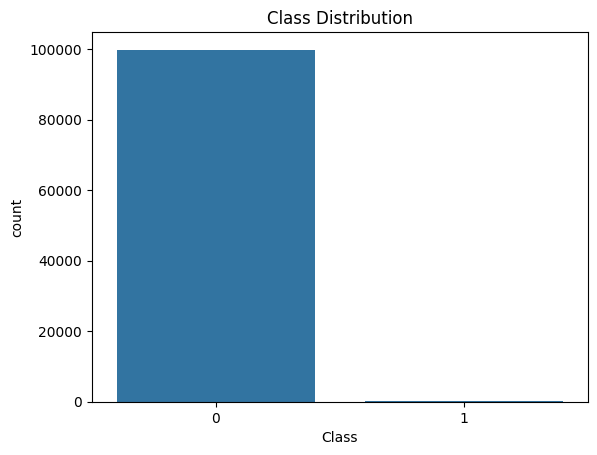

In [5]:
# Dataset info
df.info()

# Class distribution
print(df['Class'].value_counts())

# Visualization
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

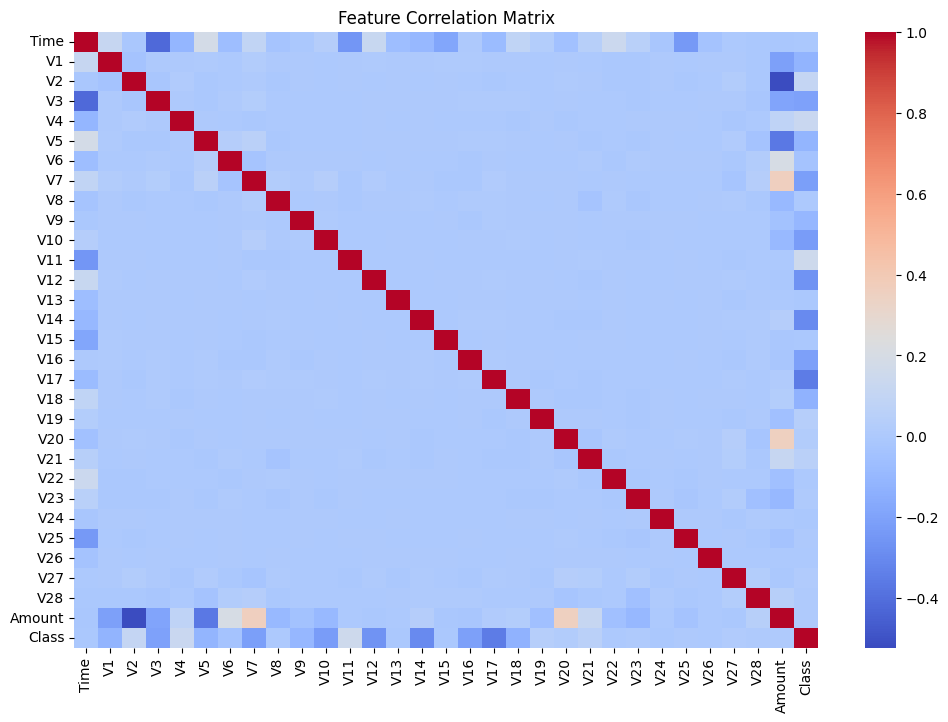

In [16]:
# Correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [6]:
# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split (important: stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y

)

In [7]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train_res).value_counts())

After SMOTE:
 Class
0    79871
1    79871
Name: count, dtype: int64


In [8]:
# Logistic Regression (baseline model for comparison)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Performance:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19968
           1       0.12      0.97      0.22        32

    accuracy                           0.99     20000
   macro avg       0.56      0.98      0.61     20000
weighted avg       1.00      0.99      0.99     20000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# Decision Tree model

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Performance:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19968
           1       0.42      0.84      0.56        32

    accuracy                           1.00     20000
   macro avg       0.71      0.92      0.78     20000
weighted avg       1.00      1.00      1.00     20000



In [10]:
# K-Nearest Neighbors model

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_res, y_train_res)

y_pred_knn = knn.predict(X_test)

print("KNN Performance:\n")
print(classification_report(y_test, y_pred_knn))

KNN Performance:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     19968
           1       0.01      0.62      0.02        32

    accuracy                           0.91     20000
   macro avg       0.51      0.77      0.49     20000
weighted avg       1.00      0.91      0.95     20000



In [11]:
# Random Forest (reduced complexity for faster training)
rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19968
           1       0.53      0.91      0.67        32

    accuracy                           1.00     20000
   macro avg       0.76      0.95      0.83     20000
weighted avg       1.00      1.00      1.00     20000



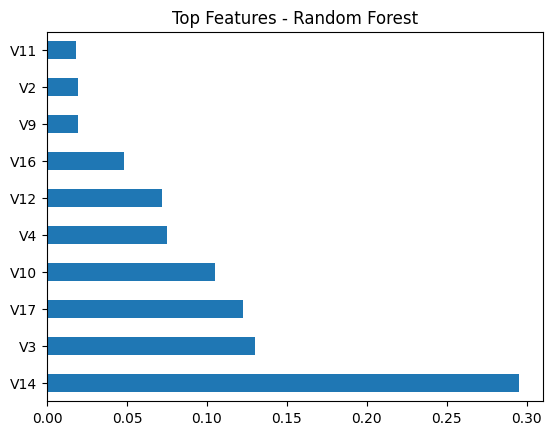

In [22]:
# Feature importance from Random Forest

rf_importances = rf.feature_importances_

feat_imp_rf = pd.Series(rf_importances, index=X.columns)
feat_imp_rf.nlargest(10).plot(kind='barh')

plt.title("Top Features - Random Forest")
plt.show()

In [21]:
# XGBoost model
xgb = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Performance:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19968
           1       0.24      0.94      0.38        32

    accuracy                           1.00     20000
   macro avg       0.62      0.97      0.69     20000
weighted avg       1.00      1.00      1.00     20000



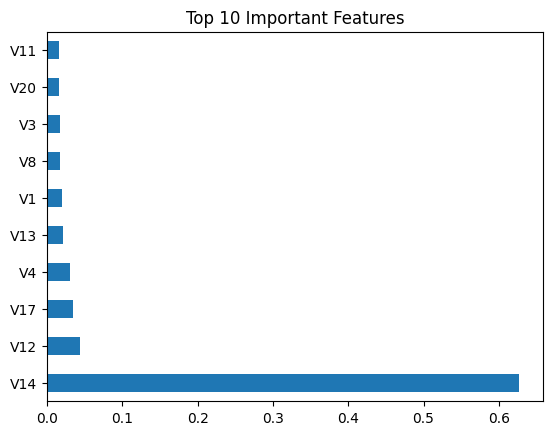

In [20]:
# Feature importance analysis using XGBoost (for interpretability)

importances = best_xgb.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [13]:
# Tuning XGBoost
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

best_xgb = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


In [14]:
# Storing results of all models for comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

def evaluate_model(name, y_true, y_pred):
    results[name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# Add all models
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.98880,0.122047,0.96875,0.216783
Decision Tree,0.99785,0.415385,0.84375,0.556701
KNN,0.91495,0.011703,0.62500,0.022975
Random Forest,0.99855,0.527273,0.90625,0.666667
XGBoost,0.99515,0.240000,0.93750,0.382166


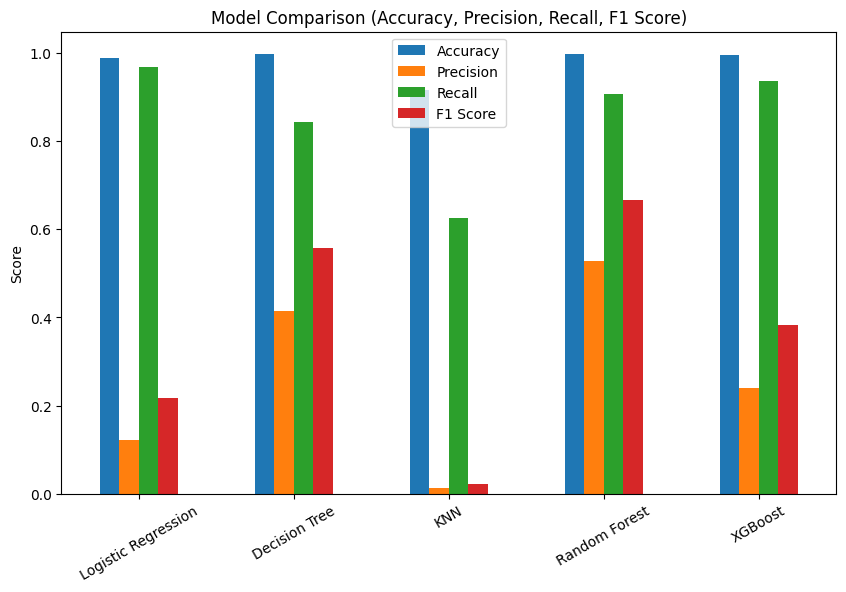

In [15]:
# Plot comparison of models

results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison (Accuracy, Precision, Recall, F1 Score)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

In [18]:
# Final model evaluation (Random Forest)

y_pred_final = rf.predict(X_test)

print("Final Model Performance:\n")
print(classification_report(y_test, y_pred_final))

Final Model Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19968
           1       0.53      0.91      0.67        32

    accuracy                           1.00     20000
   macro avg       0.76      0.95      0.83     20000
weighted avg       1.00      1.00      1.00     20000



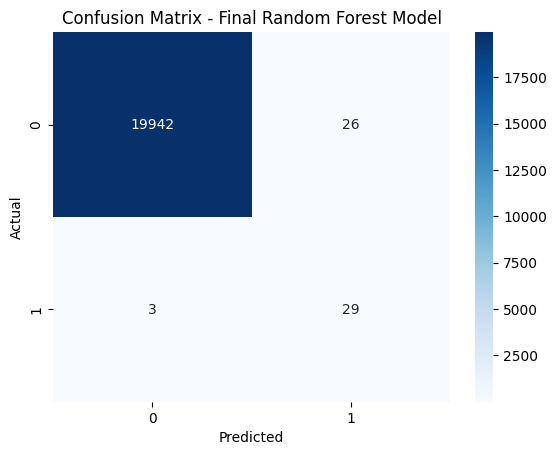

In [19]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Final Random Forest Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()